### **Intall Dependencies**

In [5]:
!pip install -q transformers accelerate datasets torch pandas

# **Confirm GPU and RAM**
You can change the Google Collab runtime:


*   -> Runtime
*   -> Change runtime type
* -> T4 GPU if on free version, A100 if pro




In [6]:
# Confirm GPU and RAM
!nvidia-smi
!torch.cuda.get_device_name(0)

Wed Dec 10 21:34:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **Load data from google drive folder**

In [8]:
from google.colab import drive, files
import pandas as pd
drive.mount('/content/drive')
df = pd.read_csv("mines.csv")
df

Mounted at /content/drive


,Context,Target
0,"Voltage: 0.338156758 V, Height: 0 cm, Soil Typ...",Mine Type: NA
1,"Voltage: 0.320241334 V, Height: 0.181818182 cm...",Mine Type: NA
2,"Voltage: 0.28700875 V, Height: 0.272727273 cm,...",Mine Type: NA
3,"Voltage: 0.256283622 V, Height: 0.454545455 cm...",Mine Type: NA
4,"Voltage: 0.262839599 V, Height: 0.545454545 cm...",Mine Type: NA
...,...,...
333,"Voltage: 0.323262478 V, Height: 0.909090909 cm...",Mine Type: M14 Anti-Personnel
334,"Voltage: 0.444108237 V, Height: 0.181818182 cm...",Mine Type: M14 Anti-Personnel
335,"Voltage: 0.353473918 V, Height: 0.454545455 cm...",Mine Type: M14 Anti-Personnel
336,"Voltage: 0.36253735 V, Height: 0.727272727 cm,...",Mine Type: M14 Anti-Personnel


# **Select precision based on GPU**

In [9]:
import os
import torch
import pandas as pd
from datetime import datetime
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from datasets import Dataset
import json

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability()
    print(f"GPU detected: {gpu_name} (Compute capability {major}.{minor})")

    # A100 / L4 GPUs support bf16
    if major >= 8:
        torch_dtype = torch.bfloat16
    else:
        torch_dtype = torch.float16
else:
    print("No GPU detected, falling back to CPU.")
    torch_dtype = torch.float32

# Cache model
os.environ["TRANSFORMERS_CACHE"] = "/content/cache"

GPU detected: Tesla T4 (Compute capability 7.5)


# **Run Model**
Outputs are saved to google drive in csv format

In [10]:
from huggingface_hub import login

from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')
login(HF_TOKEN)

# Load model and tokenizer
model_id = "google/gemma-3-4b-it"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    #torch_dtype=torch_dtype,
    dtype=torch.bfloat16,
    device_map="auto"
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto",
    batch_size=8,             # Increase based on GPU capacity
    truncation=True,
    padding=True,
    temperature=0.7,
    max_new_tokens=100,
    return_full_text=False
)


# Load data
df = df.head(8)
dataset = Dataset.from_pandas(df)

# Build all the prompts at once
def build_prompt(batch):
    return {
        "prompt": [
            f"You are a sensor expert. Given the following situation:\n"
            f"Context: {c}\nTarget: Land mine {t}\n\n"
            f"Recommend the most appropriate type of sensor to detect the target and briefly explain why. Be concise."
            for c, t in zip(batch["Context"], batch["Target"])
        ]
    }

dataset = dataset.map(build_prompt, batched=True, num_proc=4)

# Run inference
@torch.inference_mode()
def generate_recommendations(batch):
    outputs = pipe(batch["prompt"])
    return {"sensor_recommendation": [o[0]["generated_text"] for o in outputs]}

dataset = dataset.map(generate_recommendations, batched=True, batch_size=8)

# Save output
df_out = dataset.to_pandas()
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_path = f"/content/drive/MyDrive/CMDACapstone/KG{timestamp}.csv"

os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_out.to_csv(output_path, index=False)

print(f"\nSaved to: {output_path}")
print(f"Preview:")
print(df_out.head(3))

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
# interactive knowledge graph if they want it
!pip install pyvis
from neo4j import GraphDatabase
from pyvis.network import Network
import re
from collections import Counter
import os

# neo4j
URI = "neo4j+s://73684545.databases.neo4j.io"
AUTH = ("neo4j", "C21grJqwx-Ib7H0gkPt1VD6m3u3BY_4yJdt-qbPRZUs")
driver = GraphDatabase.driver(URI, auth=AUTH)

# extract keywords
stop_words = set([
    "the", "and", "is", "in", "of", "to", "a", "for", "with", "on", "as", "by", "an", "at"
])

def extract_keywords_one_word(text, top_n=1):
    words = re.findall(r'\b[a-zA-Z]{2,}\b', str(text).lower())
    counts = Counter(w for w in words if w not in stop_words)
    return [w for w, _ in counts.most_common(top_n)]

def one_word_label(label):
    if not label:
        return "N/A"
    label = os.path.splitext(str(label))[0]
    words = label.replace("_"," ").replace("-"," ").split()
    word = words[0] if words else "N/A"
    safe = ''.join(c if ord(c)<128 else '?' for c in word)
    return safe

# get nodes
with driver.session() as session:
    node_result = session.run("""
        MATCH (n)
        RETURN elementId(n) AS element_id,
               COALESCE(n.fileName, n.text, n.name, n.id) AS label
    """)
    nodes = []
    for record in node_result:
        nodes.append({
            "id": record["element_id"],
            "label": one_word_label(record["label"])
        })

    edge_result = session.run("""
        MATCH (n)-[r]->(m)
        RETURN elementId(n) AS source, elementId(m) AS target, type(r) AS rel_type
    """)
    edges = []
    for record in edge_result:
        edges.append({
            "from": record["source"],
            "to": record["target"],
            "label": record["rel_type"]
        })

# create pyvis network
net = Network(height="800px", width="100%", notebook=True, bgcolor="#ffffff", font_color="black")
net.barnes_hut()  # better for large graphs

# add nodes
for n in nodes:
    net.add_node(n["id"], label=n["label"], title=n["label"])

# add edges
for e in edges:
    net.add_edge(e["from"], e["to"], title=e["label"])

# show the graph
net.show("knowledge_graph.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.2 MB/s eta 0:00:00


ModuleNotFoundError: No module named 'neo4j'

# **Saving Attention Weights**
The transformers.pipeline() is designed for high level generation, not for low level model internals like attentions or logits. So we can't use them here.



In [ ]:
%pip install neo4j langchain langchain_openai langchain-community python-dotenv --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
import torch

# Clear PyTorch GPU memory
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Optional: print current memory status
print(torch.cuda.memory_summary(device=0))


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 1            |        cudaMalloc retries: 1         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  14207 MiB |  14207 MiB |  63497 MiB |  49290 MiB |
|       from large pool |  14155 MiB |  14155 MiB |  62423 MiB |  48267 MiB |
|       from small pool |     52 MiB |     52 MiB |   1074 MiB |   1022 MiB |
|---------------------------------------------------------------------------|
| Active memory         |  14207 MiB |  14207 MiB |  63497 MiB |  49290 MiB |
|       from large pool |  14155 MiB |  14155 MiB |  62423 MiB |

Adjacency matrix shape: (4072, 4072)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 61549 (\uf06d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 119808 (\N{MATHEMATICAL BOLD CAPITAL A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 119924 (\N{MATHEMATICAL BOLD ITALIC CAPITAL M}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 119820 (\N{MATHEMATICAL BOLD CAPITAL M}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 119826 (\N{MATHEMATICAL BOLD CAPITAL S}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fi

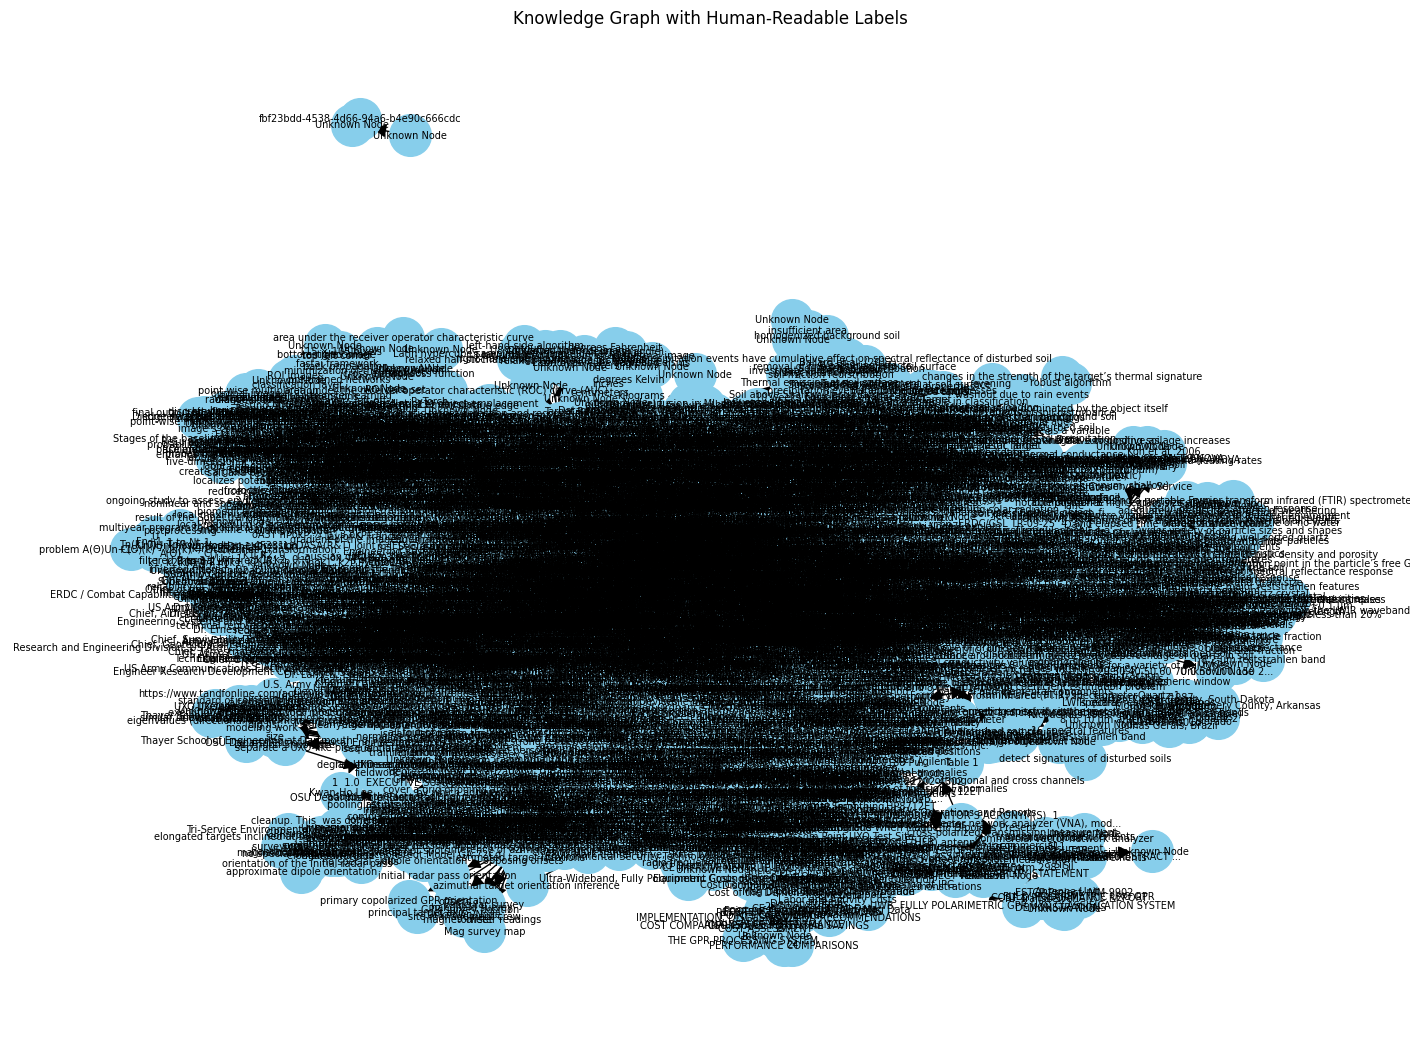

In [ ]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
import numpy as np

# neo4j connection
URI = "neo4j+s://73684545.databases.neo4j.io"
AUTH = ("neo4j", "C21grJqwx-Ib7H0gkPt1VD6m3u3BY_4yJdt-qbPRZUs")
driver = GraphDatabase.driver(URI, auth=AUTH)

G = nx.DiGraph()

def make_label(properties):
    """
    Convert node properties into readable label text.
    Priority:
        1. text (shortened)
        2. fileName + page_number
        3. type
        4. element ID
    """
    # if node has "text"
    if "text" in properties and properties["text"]:
        t = properties["text"].strip().replace("\n", " ")
        return t[:60] + "..." if len(t) > 60 else t

    # if node has filename + page
    if "fileName" in properties and "page_number" in properties:
        return f"{properties['fileName']} (page {properties['page_number']})"

    # if node has a type
    if "type" in properties:
        return properties["type"]

    # element id
    return properties.get("id", properties.get("element_id", "Unknown Node"))

# query
node_ids = []
edges = []

with driver.session() as session:
    results = session.run("MATCH (n)-[r]->(m) RETURN n, r, m")

    for record in results:
        n = record["n"]
        m = record["m"]

        # Internal unique IDs
        n_id = n.element_id
        m_id = m.element_id

        # Add nodes with human-readable labels
        G.add_node(n_id, label=make_label(n))
        G.add_node(m_id, label=make_label(m))

        # Record edges
        edges.append((n_id, m_id))

# add edges to graph (relationships)
G.add_edges_from(edges)

# build matrix
node_list = sorted(G.nodes())
adj_matrix = nx.to_numpy_array(G, nodelist=node_list)

print("Adjacency matrix shape:", adj_matrix.shape)

# visualize
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42)

node_labels = nx.get_node_attributes(G, "label")

nx.draw(
    G,
    pos,
    labels=node_labels,
    with_labels=True,
    node_color="skyblue",
    node_size=900,
    font_size=7,
    arrowsize=20
)

plt.title("Knowledge Graph with Human-Readable Labels")
plt.show()

In [ ]:
# debugging to be sure it is finding the files
with driver.session() as session:
    records = session.run("MATCH (n) RETURN n LIMIT 5")
    for r in records:
        print(dict(r["n"]))

NameError: name 'driver' is not defined

In [ ]:
# returns the node labels to be sure it is a meaningful value
for node in G.nodes():
    print(G.nodes[node]["label"])

In [ ]:
import os
import torch
import pandas as pd
from datetime import datetime
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset
import json
import zipfile
from tqdm import tqdm
from neo4j import GraphDatabase
import networkx as nx

# connext to neo4j instance

URI = "neo4j+s://73684545.databases.neo4j.io"
AUTH = ("neo4j", "C21grJqwx-Ib7H0gkPt1VD6m3u3BY_4yJdt-qbPRZUs")
driver = GraphDatabase.driver(URI, auth=AUTH)

# create graph
G = nx.DiGraph()

def make_label(properties):
    """
    Convert node properties into readable label text.
    Priority:
        1. text (shortened)
        2. fileName + page_number
        3. type
        4. element ID
    """
    # if node has "text"
    if "text" in properties and properties["text"]:
        t = properties["text"].strip().replace("\n", " ")
        return t[:60] + "..." if len(t) > 60 else t

    # if node has filename + page
    if "fileName" in properties and "page_number" in properties:
        return f"{properties['fileName']} (page {properties['page_number']})"

    # if node has a type
    if "type" in properties:
        return properties["type"]

    # if everything else fails, element id
    return properties.get("id", properties.get("element_id", "Unknown Node"))

# query and generate graph
node_ids = []
edges = []

with driver.session() as session:
    results = session.run("MATCH (n)-[r]->(m) RETURN n, r, m")

    for record in results:
        n = record["n"]
        m = record["m"]

        # unique node IDs
        n_id = n.element_id
        m_id = m.element_id

        # give the nodes labels
        G.add_node(n_id, label=make_label(n))
        G.add_node(m_id, label=make_label(m))

        # record edges
        edges.append((n_id, m_id))

# add edges to graph
G.add_edges_from(edges)

# get the most important nodes in the knowledge graph
centrality = nx.degree_centrality(G)
sorted_nodes = sorted(centrality.items(), key=lambda x: -x[1])
top_k = 10  # you can tune

global_kg_context = [
    G.nodes[node]["label"] for node, _ in sorted_nodes[:top_k]
]

# Pre-extract node and edge structures for fast lookup
node_list = []
node_lookup = {}   # node_id → lowercase label

for node_id, data in G.nodes(data=True):
    label = data["label"]
    node_list.append((node_id, label))
    node_lookup[node_id] = label.lower()

# adjacency: node_id → list of (neighbor_id, relationship_label)
adjacency = {node_id: [] for node_id, _ in node_list}

for u, v, data in G.edges(data=True):
    rel = data.get("label") or data.get("type") or "related_to"
    adjacency[u].append((v, rel))
    adjacency[v].append((u, rel))

# load gemma
model_id = "google/gemma-3-4b-it"
torch_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    device_map="auto"
)
model.eval()
model.set_attn_implementation("eager")
model.config.use_cache = False

# load mines.csv
df = pd.read_csv("mines.csv")
df = df.head(2)  # testing
dataset = Dataset.from_pandas(df)

# prompt with knowledge graph context
def get_kg_context_for_row(context, max_nodes=5, max_edges=5):
    """
    Query Neo4j for nodes and edges matching the row context.
    Only returns a small subset per row to save RAM.
    """
    query = f"""
    MATCH (n)-[r]->(m)
    WHERE any(word IN split($context, ' ') WHERE n.text CONTAINS word OR m.text CONTAINS word)
    RETURN n, r, m
    LIMIT $max_total
    """
    max_total = max_nodes + max_edges
    with driver.session() as session:
        results = session.run(query, context=context, max_total=max_total)
        nodes, edges = set(), []
        for record in results:
            n_label = make_label(record["n"])
            m_label = make_label(record["m"])
            nodes.update([n_label, m_label])
            rel_label = record["r"].type if record["r"].type else "related_to"
            edges.append(f"{n_label} —[{rel_label}]→ {m_label}")
        return list(nodes)[:max_nodes], edges[:max_edges]

def build_prompt_with_kg(batch):
    prompts = []
    for context, target in zip(batch["Context"], batch["Target"]):
        node_labels, edge_text = get_kg_context_for_row(context)
        node_text = " | ".join(node_labels) if node_labels else "None"
        edge_text = "\n".join(edge_text) if edge_text else "None"

        prompt = (
            f"You are a sensor expert. Given the following situation:\n"
            f"Context: {context}\n\n"
            f"Relevant KG Nodes: {node_text}\n"
            f"Relevant KG Relationships:\n{edge_text}\n\n"
            f"Target: Land mine {target}\n\n"
            f"Recommend the most appropriate type of sensor..."
        )
        prompts.append(prompt)
    return {"prompt": prompts}


dataset = dataset.map(build_prompt_with_kg, batched=True)

# output location
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
base_dir = f"/content/drive/MyDrive/CMDACapstone_{timestamp}"
attn_dir = os.path.join(base_dir, "attentions")
os.makedirs(attn_dir, exist_ok=True)

# extract attention matrices

@torch.inference_mode()
def generate_with_attentions(batch, indices):
    responses, attn_files = [], []

    for prompt, idx in zip(batch["prompt"], indices):
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(model.device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.7,
            return_dict_in_generate=True,
            output_attentions=True
        )

        full_response = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True).strip()
        responses.append(full_response)

        if outputs.attentions is not None:
            final_step = outputs.attentions[-1]  # last token generation
            mean_layers = []
            for layer_attn in final_step:
                if isinstance(layer_attn, torch.Tensor):
                    mean_layers.append(layer_attn.mean(dim=(0, 1)))  # mean over batch & heads

            mean_layers = [layer.cpu().tolist() for layer in mean_layers]
            attn_path = os.path.join(attn_dir, f"attn_{idx:04d}.json")
            with open(attn_path, "w") as f:
                json.dump({"mean_attention_final_step": mean_layers}, f)
            attn_files.append(attn_path)
        else:
            attn_files.append(None)

    return {"full_response": responses, "attention_file": attn_files}

dataset = dataset.map(
    generate_with_attentions,
    with_indices=True,
    batched=True,
    batch_size=8
)

# csv file
df_out = dataset.to_pandas()[["full_response", "attention_file"]]
csv_path = os.path.join(base_dir, "sensor_recommendations.csv")
df_out.to_csv(csv_path, index=False)

# zip file
zip_path = os.path.join(base_dir, "attentions_full.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for f in tqdm(os.listdir(attn_dir), total=len(os.listdir(attn_dir)), leave=False):
        full_path = os.path.join(attn_dir, f)
        zipf.write(full_path, arcname=f)

print(f"CSV Saved: {csv_path}")
print(f"Attention JSONs: {attn_dir}")
print(f"Zipped attentions: {zip_path}")
print(df_out.head(3))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Parameter 'function'=<function build_prompt_with_kg at 0x7a92f5cd8180> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

In [ ]:
import os
import torch
import pandas as pd
from datetime import datetime
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset
import json
import zipfile
from tqdm import tqdm
from neo4j import GraphDatabase
import networkx as nx
import re

# ----------------------------
# Connect to Neo4j
# ----------------------------
URI = "neo4j+s://73684545.databases.neo4j.io"
AUTH = ("neo4j", "C21grJqwx-Ib7H0gkPt1VD6m3u3BY_4yJdt-qbPRZUs")
driver = GraphDatabase.driver(URI, auth=AUTH)

# ----------------------------
# Build graph from Neo4j
# ----------------------------
G = nx.DiGraph()

def make_label(properties):
    """Convert node properties into readable label text."""
    if "text" in properties and properties["text"]:
        t = properties["text"].strip().replace("\n", " ")
        return t[:60] + "..." if len(t) > 60 else t
    if "fileName" in properties and "page_number" in properties:
        return f"{properties['fileName']} (page {properties['page_number']})"
    if "type" in properties:
        return properties["type"]
    return properties.get("id", properties.get("element_id", "Unknown Node"))

with driver.session() as session:
    results = session.run("MATCH (n)-[r]->(m) RETURN n, r, m")
    for record in results:
        n = record["n"]
        m = record["m"]
        r = record["r"]

        n_id = n.element_id
        m_id = m.element_id

        G.add_node(n_id, label=make_label(n))
        G.add_node(m_id, label=make_label(m))

        # store relation type if exists
        rel_type = getattr(r, "type", "is related to")
        G.add_edge(n_id, m_id, relation=rel_type)

# ----------------------------
# Helper functions
# ----------------------------
def text_to_words(text):
    """Lowercase and split text into unique words."""
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return set(text.split())

# ----------------------------
# Build KG context per row (sentence-style)
# ----------------------------
# ----------------------------
# Build KG context per row (sentence-style, using nodes + edges)
# ----------------------------
def build_prompt_with_kg(batch, max_nodes=5, max_edges=10):
    prompts = []

    for context, target in zip(batch["Context"], batch["Target"]):
        context_words = text_to_words(context)

        # Score nodes by keyword overlap with context
        node_scores = []
        for node in G.nodes():
            label_words = text_to_words(G.nodes[node]["label"])
            score = len(context_words & label_words)
            if score > 0:
                node_scores.append((node, score))

        # Fallback: use top central nodes if no matches
        if not node_scores:
            centrality = nx.degree_centrality(G)
            sorted_nodes = sorted(centrality.items(), key=lambda x: -x[1])
            top_nodes = [node for node, _ in sorted_nodes[:max_nodes]]
        else:
            node_scores.sort(key=lambda x: -x[1])
            top_nodes = [n for n, _ in node_scores[:max_nodes]]

        # Collect relevant edges connected to top nodes
        relevant_edges = []
        for u, v, data in G.edges(data=True):
            if u in top_nodes or v in top_nodes:
                u_label = G.nodes[u].get("label", f"Unknown Node ({u})")
                v_label = G.nodes[v].get("label", f"Unknown Node ({v})")
                relation = data.get("relation", "is related to")
                relevant_edges.append(f"{u_label} {relation} {v_label}.")

        # Limit number of edges for prompt
        relevant_edges = relevant_edges[:max_edges]
        kg_text = " ".join(relevant_edges)

        # Build prompt
        prompt = (
            f"You are a sensor expert. Given the following situation:\n"
            f"Context: {context}\n"
            f"KG context: {kg_text}\n"
            f"Target: Land mine {target}\n\n"
            f"Recommend the most appropriate type of sensor..."
        )
        prompts.append(prompt)

    return {"prompt": prompts}


# ----------------------------
# Load dataset
# ----------------------------
df = pd.read_csv("mines.csv")
df = df.head(2)  # testing
dataset = Dataset.from_pandas(df)

dataset = dataset.map(
    lambda batch: build_prompt_with_kg(batch),
    batched=True
)

# ----------------------------
# Load GEMMA model
# ----------------------------
model_id = "google/gemma-3-4b-it"
torch_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    device_map="auto"
)
model.eval()
model.set_attn_implementation("eager")
model.config.use_cache = False

# ----------------------------
# Output paths
# ----------------------------
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
base_dir = f"/content/drive/MyDrive/CMDACapstone_{timestamp}"
attn_dir = os.path.join(base_dir, "attentions")
os.makedirs(attn_dir, exist_ok=True)

# ----------------------------
# Extract attention matrices
# ----------------------------
# ----------------------------
# Attention extraction: row-by-row (low GPU usage)
# ----------------------------
@torch.inference_mode()
def generate_row_by_row(dataset, tokenizer, model, attn_dir, max_new_tokens=100, max_kg_tokens=200):
    responses = []
    attn_files = []

    for idx, row in enumerate(dataset):
        # truncate KG context if too long
        prompt = row["prompt"]
        tokenized = tokenizer(prompt, truncation=True, padding=True, return_tensors="pt").to(model.device)

        # generate response with attention
        outputs = model.generate(
            **tokenized,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            return_dict_in_generate=True,
            output_attentions=True
        )

        # decode response
        full_response = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True).strip()
        responses.append(full_response)

        # save attentions if they exist
        if outputs.attentions is not None:
            # keep only last layer, mean over heads & batch
            last_layer = outputs.attentions[-1]
            mean_attn = [layer.mean(dim=(0,1)).cpu().tolist() for layer in last_layer]

            attn_path = os.path.join(attn_dir, f"attn_{idx:04d}.json")
            with open(attn_path, "w") as f:
                json.dump({"mean_attention_final_step": mean_attn}, f)
            attn_files.append(attn_path)
        else:
            attn_files.append(None)

        # free GPU memory
        del tokenized, outputs
        torch.cuda.empty_cache()

    return {"full_response": responses, "attention_file": attn_files}

# ----------------------------
# Run on dataset
# ----------------------------
results = generate_row_by_row(dataset, tokenizer, model, attn_dir)

# ----------------------------
# Save CSV
# ----------------------------
df_out = pd.DataFrame(results)
csv_path = os.path.join(base_dir, "sensor_recommendations.csv")
df_out.to_csv(csv_path, index=False)
print(f"CSV Saved: {csv_path}")

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


CSV Saved: /content/drive/MyDrive/CMDACapstone_2025-12-01_20-04-06/sensor_recommendations.csv


In [ ]:
import os
import torch
import pandas as pd
from datetime import datetime
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset
import json
import zipfile
from tqdm import tqdm
from neo4j import GraphDatabase
import networkx as nx
import re

# ----------------------------
# Connect to Neo4j
# ----------------------------
URI = "neo4j+s://73684545.databases.neo4j.io"
AUTH = ("neo4j", "C21grJqwx-Ib7H0gkPt1VD6m3u3BY_4yJdt-qbPRZUs")
driver = GraphDatabase.driver(URI, auth=AUTH)

# ----------------------------
# Build graph from Neo4j
# ----------------------------
G = nx.DiGraph()

def make_label(properties):
    """
    Convert node properties into readable label text.
    Priority:
        1. text (shortened)
        2. fileName + page_number
        3. type
        4. element ID
    """
    # if node has "text"
    if "text" in properties and properties["text"]:
        t = properties["text"].strip().replace("\n", " ")
        return t[:60] + "..." if len(t) > 60 else t

    # if node has filename + page
    if "fileName" in properties and "page_number" in properties:
        return f"{properties['fileName']} (page {properties['page_number']})"

    # if node has a type
    if "type" in properties:
        return properties["type"]

    # if everything else fails, element id
    return properties.get("id", properties.get("element_id", "Unknown Node"))

# query and generate graph
node_ids = []
edges = []

with driver.session() as session:
    results = session.run("MATCH (n)-[r]->(m) RETURN n, r, m")

    for record in results:
        n = record["n"]
        m = record["m"]

        # unique node IDs
        n_id = n.element_id
        m_id = m.element_id

        # give the nodes labels
        G.add_node(n_id, label=make_label(n))
        G.add_node(m_id, label=make_label(m))

        # record edges
        edges.append((n_id, m_id))

# add edges to graph
G.add_edges_from(edges)

# get the most important nodes in the knowledge graph
centrality = nx.degree_centrality(G)
sorted_nodes = sorted(centrality.items(), key=lambda x: -x[1])
top_k = 10  # you can tune

global_kg_context = [
    G.nodes[node]["label"] for node, _ in sorted_nodes[:top_k]
]

# load gemma
model_id = "google/gemma-3-4b-it"
torch_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    device_map="auto"
)
model.eval()
model.set_attn_implementation("eager")
model.config.use_cache = False

# load mines.csv
df = pd.read_csv("mines.csv")
df = df.head(2)  # testing
dataset = Dataset.from_pandas(df)

# get top-K nodes based on centrality
centrality = nx.degree_centrality(G)
sorted_nodes = sorted(centrality.items(), key=lambda x: -x[1])
top_k = 10  # you can tune
top_nodes = [node for node, _ in sorted_nodes[:top_k]]

# build global KG context with edges
global_kg_context = []
for node in top_nodes:
    node_label = G.nodes[node].get("label", str(node))
    for neighbor in G.neighbors(node):
        neighbor_label = G.nodes[neighbor].get("label", str(neighbor))
        edge_data = G.get_edge_data(node, neighbor)
        if edge_data:
            # take first edge type if multiple edges
            relation = edge_data[list(edge_data.keys())[0]].get("relation", "related_to")
        else:
            relation = "related_to"
        global_kg_context.append(f"{node_label} --[{relation}]--> {neighbor_label}")

# ----------------------------
# Helper: text_to_words
# ----------------------------
def text_to_words(text):
    """Lowercase and split text into unique words."""
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return set(text.split())

# prompt with knowledge graph context
# ----------------------------
# Build KG context per row (using nodes + edges)
# ----------------------------
def build_prompt_with_kg(batch, max_nodes=5, max_edges=10):
    """
    For each row in the batch, build a prompt that includes:
    - The row's Context and Target
    - Relevant KG nodes and edges as sentences
    """
    prompts = []

    for context, target in zip(batch["Context"], batch["Target"]):
        context_words = text_to_words(context)

        # Score nodes by keyword overlap with context
        node_scores = []
        for node in G.nodes():
            label_words = text_to_words(G.nodes[node]["label"])
            score = len(context_words & label_words)
            if score > 0:
                node_scores.append((node, score))

        # If no overlap, use top central nodes
        if not node_scores:
            centrality = nx.degree_centrality(G)
            sorted_nodes = sorted(centrality.items(), key=lambda x: -x[1])
            top_nodes = [node for node, _ in sorted_nodes[:max_nodes]]
        else:
            node_scores.sort(key=lambda x: -x[1])
            top_nodes = [n for n, _ in node_scores[:max_nodes]]

        # Collect relevant edges connected to top nodes
        relevant_edges = []
        for u, v, data in G.edges(data=True):
            if u in top_nodes or v in top_nodes:
                u_label = G.nodes[u].get("label", f"Unknown Node ({u})")
                v_label = G.nodes[v].get("label", f"Unknown Node ({v})")
                relation = data.get("relation", "is related to")
                relevant_edges.append(f"{u_label} {relation} {v_label}.")

        # Limit number of edges included
        relevant_edges = relevant_edges[:max_edges]
        kg_text = " ".join(relevant_edges)

        # Build final prompt
        prompt = (
            f"You are a sensor expert. Given the following situation:\n"
            f"Context: {context}\n"
            f"KG context: {kg_text}\n"
            f"Target: Land mine {target}\n\n"
            f"Recommend the most appropriate type of sensor..."
        )
        prompts.append(prompt)

    return {"prompt": prompts}

dataset = dataset.map(
    lambda batch: build_prompt_with_kg(batch), # Removed global_kg_context as an argument here
    batched=True
)


# output location
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
base_dir = f"/content/drive/MyDrive/CMDACapstone_{timestamp}"
attn_dir = os.path.join(base_dir, "attentions")
os.makedirs(attn_dir, exist_ok=True)

# ----------------------------
# Efficient row-by-row generator
# ----------------------------
@torch.inference_mode()
def generate_row_by_row(df, tokenizer, model, G, attn_dir, max_nodes=5, max_edges=10, max_new_tokens=100):
    """
    Generate responses with attention row-by-row to minimize RAM usage.
    Saves attentions and responses incrementally.
    """
    os.makedirs(attn_dir, exist_ok=True)
    rows_out = []

    centrality = nx.degree_centrality(G)
    sorted_central = sorted(centrality.items(), key=lambda x: -x[1])
    top_global_nodes = [node for node, _ in sorted_central[:max_nodes]]

    for idx, row in df.iterrows():
        context = row["Context"]
        target = row["Target"]
        context_words = text_to_words(context)

        # ----------------------------
        # Score nodes by keyword overlap
        # ----------------------------
        node_scores = []
        for node in G.nodes():
            label_words = text_to_words(G.nodes[node]["label"])
            score = len(context_words & label_words)
            if score > 0:
                node_scores.append((node, score))

        if not node_scores:
            top_nodes = top_global_nodes
        else:
            node_scores.sort(key=lambda x: -x[1])
            top_nodes = [n for n, _ in node_scores[:max_nodes]]

        # ----------------------------
        # Collect relevant edges
        # ----------------------------
        relevant_edges = []
        for u, v, data in G.edges(data=True):
            if u in top_nodes or v in top_nodes:
                u_label = G.nodes[u].get("label", f"Unknown Node ({u})")
                v_label = G.nodes[v].get("label", f"Unknown Node ({v})")
                relation = data.get("relation", "is related to")
                relevant_edges.append(f"{u_label} {relation} {v_label}.")

        relevant_edges = relevant_edges[:max_edges]
        kg_text = " ".join(relevant_edges)

        # ----------------------------
        # Build prompt
        # ----------------------------
        prompt = (
            f"You are a sensor expert. Given the following situation:\n"
            f"Context: {context}\n"
            f"KG context: {kg_text}\n"
            f"Target: Land mine {target}\n\n"
            f"Recommend the most appropriate type of sensor..."
        )

        # ----------------------------
        # Tokenize & generate
        # ----------------------------
        tokenized = tokenizer(prompt, truncation=True, padding=True, return_tensors="pt").to(model.device)
        outputs = model.generate(
            **tokenized,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            return_dict_in_generate=True,
            output_attentions=True
        )

        # ----------------------------
        # Decode response
        # ----------------------------
        full_response = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True).strip()

        # ----------------------------
        # Save attentions
        # ----------------------------
        if outputs.attentions is not None:
            last_layer = outputs.attentions[-1]
            mean_attn = [layer.mean(dim=(0,1)).cpu().tolist() for layer in last_layer]

            attn_path = os.path.join(attn_dir, f"attn_{idx:04d}.json")
            with open(attn_path, "w") as f:
                json.dump({"mean_attention_final_step": mean_attn}, f)
        else:
            attn_path = None

        rows_out.append({"full_response": full_response, "attention_file": attn_path})

        # ----------------------------
        # Free memory
        # ----------------------------
        del tokenized, outputs
        torch.cuda.empty_cache()

        if (idx+1) % 10 == 0:
            print(f"Processed {idx+1}/{len(df)} rows")

    return pd.DataFrame(rows_out)

# ----------------------------
# Run row-by-row generation
# ----------------------------
df_out = generate_row_by_row(df, tokenizer, model, G, attn_dir)

# ----------------------------
# Save CSV
# ----------------------------
csv_path = os.path.join(base_dir, "sensor_recommendations.csv")
df_out.to_csv(csv_path, index=False)
print(f"CSV Saved: {csv_path}")

# ----------------------------
# Zip attentions
# ----------------------------
zip_path = os.path.join(base_dir, "attentions_full.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for f in tqdm(os.listdir(attn_dir), total=len(os.listdir(attn_dir)), leave=False):
        full_path = os.path.join(attn_dir, f)
        zipf.write(full_path, arcname=f)

print(f"Attention JSONs: {attn_dir}")
print(f"Zipped attentions: {zip_path}")
print(df_out.head(3))

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


CSV Saved: /content/drive/MyDrive/CMDACapstone_2025-12-01_20-16-26/sensor_recommendations.csv


Attention JSONs: /content/drive/MyDrive/CMDACapstone_2025-12-01_20-16-26/attentions
Zipped attentions: /content/drive/MyDrive/CMDACapstone_2025-12-01_20-16-26/attentions_full.zip
                                       full_response  \
0  You are a sensor expert. Given the following s...   
1  You are a sensor expert. Given the following s...   

                                      attention_file  
0  /content/drive/MyDrive/CMDACapstone_2025-12-01...  
1  /content/drive/MyDrive/CMDACapstone_2025-12-01...  
